## **Tuning**

In [ ]:
from hapcancer.cli.functions import tuning_api
 
# -- BASE CONFIGURATION
config_dir = "path_to"
config_defaults = {
    "birads_classifier": "birads_clf_001.yml",
    "embeddings": "tfidf_001.yml",
    "split": "split_002.yml",
    "followup": "fix_grace_90_birads5_interval_6.yml", # -- not relevant for this phase, but probably going to raise an error if 'None'
    "bmi_model": None,
    "tuning": "bce_only_features.yml",
    "training_experiments": "base.yml",
    "eval": None
}

#target_years = [ 5, 4, 1 ]
#for cur_target_year in target_years:
#    print(f"Target year: {cur_target_year}")
#    tuning_api(
#        config_dir=config_dir,
#        config_defaults=config_defaults,
#        target_year=cur_target_year,
#        seq_percentile=99.5,
#        n_splits=5,
#        total_epochs_per_trial=15,
#        ablate=False
#    )

## **Training (Best configuration)**

In [ ]:
from hapcancer.cli.functions import cv_training_best_api
from hapcancer.eval.log_manager import TuningLogManager

# -- BASE CONFIGURATION
config_dir = "path_to"
config_defaults = {
    "birads_classifier": "birads_clf_001.yml",
    "embeddings": "tfidf_001.yml",
    "split": "split_002.yml",
    "followup": "fix_grace_90_birads5_interval_6.yml", # -- not relevant for this phase, but probably going to raise an error if 'None'
    "bmi_model": None,
    "tuning": "bce_filtering_shortcuts.yml",
    "training_experiments": "base.yml",
    "eval": None
}

target_years = [ 5, 4, 3, 2, 1 ]
strat_str = config_defaults["followup"].split(".")[0]
split_str = config_defaults["split"].split(".")[0]

tuninglog = TuningLogManager(config_dir, config_defaults)
best_params = { yr: tuninglog.get_best_trial_params(strat_str, target_year=yr, split_str=split_str) for yr in target_years }
best_params_names = { yr: tuninglog.get_model_name(trial_number=best_params[yr][0], strat_str=strat_str, target_year=yr, split_str=split_str) for yr in target_years }

for yr in target_years:
    print(yr, best_params[yr])
    print(yr, best_params_names[yr])
    print("--")

#for cur_target_year in target_years:
#    print(f"Target year: {cur_target_year}")
#    cv_training_best_api(
#        config_dir=config_dir,
#        config_defaults=config_defaults,
#        target_year=cur_target_year,
#        seq_percentile=99.5,
#        n_splits=5, 
#        ablate=False
#    )

5 (26, {'dropout': 0.4442269276642232, 'depth': 3, 'layer_0_units': 64, 'layer_1_units': 64, 'layer_2_units': 16, 'weight_decay': 6.9073359861195e-05, 'learning_rate': 0.0010561776537043367, 'optimizer': 'sgd'}, 0.8625688100429807)
5 trial_26_5yr_id_10078f8ac43cf2b5
--
4 (29, {'dropout': 0.2088759897514147, 'depth': 3, 'layer_0_units': 32, 'layer_1_units': 256, 'layer_2_units': 1024, 'weight_decay': 5.10018303078044e-05, 'learning_rate': 0.00043640748103768813, 'optimizer': 'adam'}, 0.845164526791209)
4 trial_29_4yr_id_2c09b6bd084fb2b2
--
3 (2, {'dropout': 0.24843359269174098, 'depth': 4, 'layer_0_units': 512, 'layer_1_units': 1024, 'layer_2_units': 128, 'layer_3_units': 128, 'weight_decay': 0.0007054524987869416, 'learning_rate': 0.0006304469295312829, 'optimizer': 'adam'}, 0.8337222224211578)
3 trial_2_3yr_id_71b9125749405d14
--
2 (4, {'dropout': 0.4842631173712675, 'depth': 3, 'layer_0_units': 16, 'layer_1_units': 1024, 'layer_2_units': 1024, 'weight_decay': 0.000347125409003724, 'l

## **Eval**

c:\Users\Higor Monteiro\anaconda3\envs\hapcancer\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2 (4, {'dropout': 0.4842631173712675, 'depth': 3, 'layer_0_units': 16, 'layer_1_units': 1024, 'layer_2_units': 1024, 'weight_decay': 0.000347125409003724, 'learning_rate': 9.107329229641331e-05, 'optimizer': 'sgd'}, 0.7960280772171564)
2 trial_4_2yr_id_90dfcc5d49670166
--
1 (22, {'dropout': 0.09182326909170041, 'depth': 4, 'layer_0_units': 512, 'layer_1_units': 64, 'layer_2_units': 32, 'layer_3_units': 512, 'weight_decay': 3.7878709735406965e-06, 'learning_rate': 1.0205025629114007e-05, 'optimizer': 'adam'}, 0.8161300100769617)
1 trial_22_1yr_id_cd1ca75ec00fafb8
--
Target year: 2
Extracting model outputs: 


  0%|          | 0/5 [00:00<?, ?it/s]

trial_4_2yr_id_90dfcc5d49670166
{'config_dir_path': 'D:\\hapvida\\config\\collection_06012026_fix', 'split_config_name': 'split_002', 'training_config_name': 'trial_4_2yr_id_90dfcc5d49670166', 'epoch': 0, 'target year': 2, 'training metrics': {'CV': 0, 'Loss': 0.6719489305682437, 'AUROC': 0.6314860537974398, 'Average Precision': 0.605066357259251}, 'validation metrics': {'CV': 0, 'Loss': 0.4884465343501793, 'AUROC': 0.7196689587009921, 'Average Precision': 0.008076809053225487, 'Learning Rate': 9.107329229641331e-05}}


27it [00:02,  9.17it/s]


...

maximum sequence size found: 36
maximum sequence size after removal of outliers: 16.0
before filtering of shortcut terms: (383795, 65)
after filtering of shortcut terms: (366464, 64)
standardization was done here
before transform: (366464, 64)
after transform: (366464, 66)
positives: 419
(366464, 67)
before filtering of shortcut terms: (481019, 65)
after filtering of shortcut terms: (459424, 64)
standardization was done here
before transform: (459424, 64)
after transform: (459424, 66)
positives: 564
(459424, 67)


loaded emb vector: D:\hapvida\load\collection_06012026\fix_grace_90_birads5_interval_6\mammogram_id_embeddings_36_tfidf_mammograms_001.lmdb


2863it [02:25, 19.63it/s]
3590it [00:48, 73.80it/s]
100%|██████████| 5/5 [26:01<00:00, 312.23s/it]
27it [00:03,  8.94it/s]


maximum sequence size found: 36
maximum sequence size after removal of outliers: 16.0


  0%|          | 0/5 [00:00<?, ?it/s]C:\Users\Higor Monteiro\Documents\code\breast-cancer-hapvida\src\hapcancer\eval\metrics.py:434: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend(loc=legend_loc, prop={'size': legend_size}, frameon=False)
100%|██████████| 5/5 [00:00<00:00, 15.60it/s]


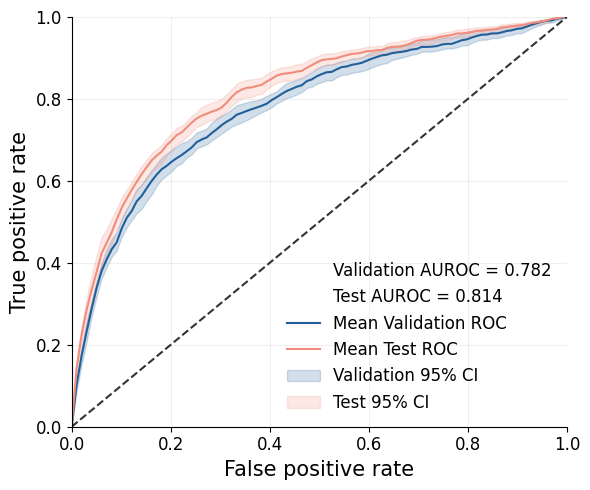

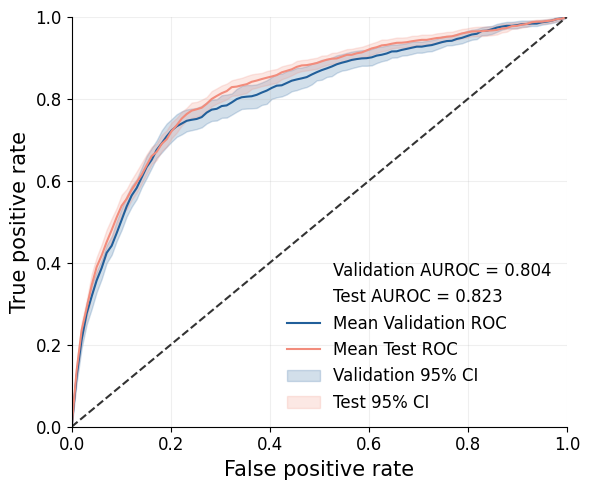

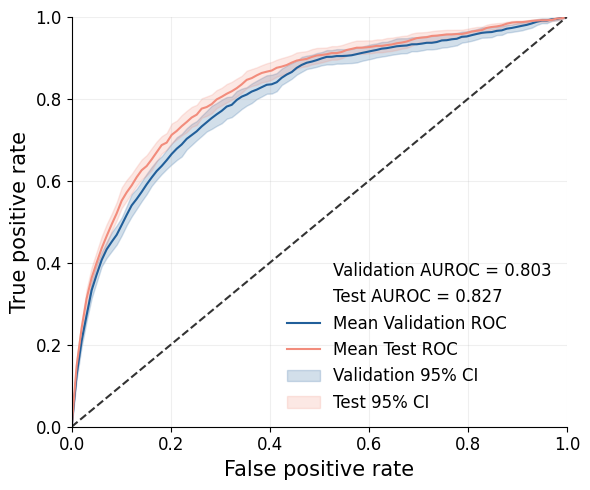

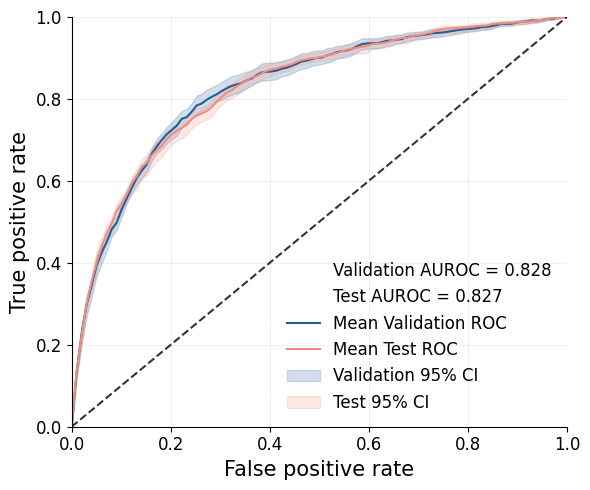

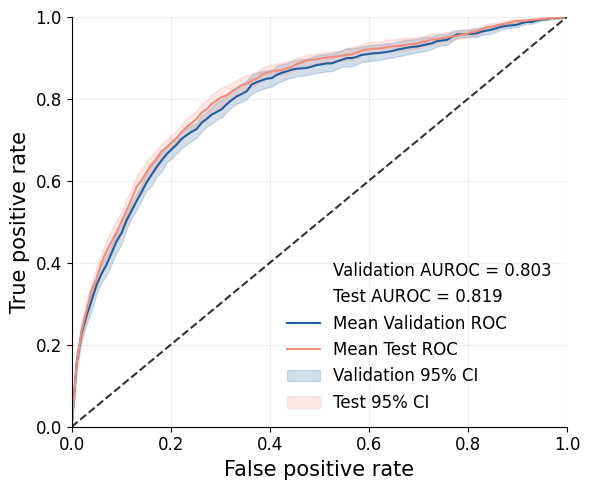

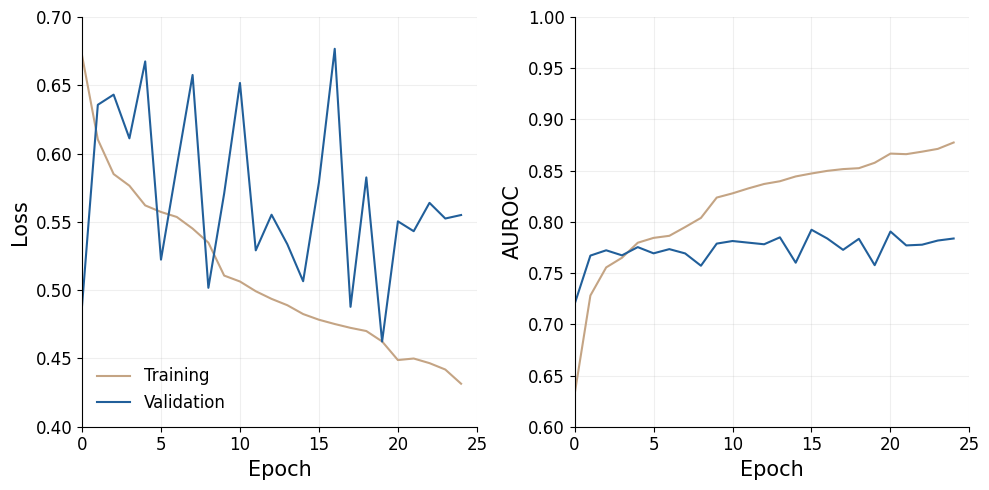

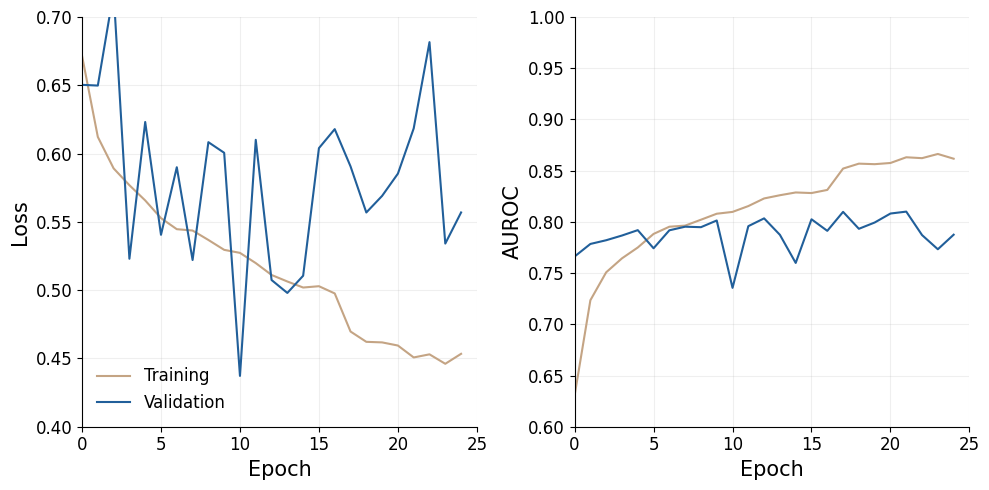

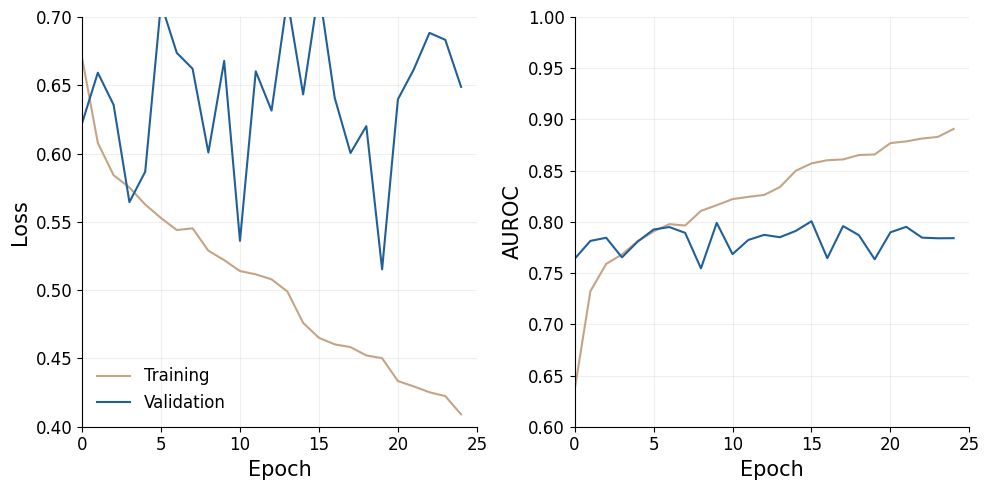

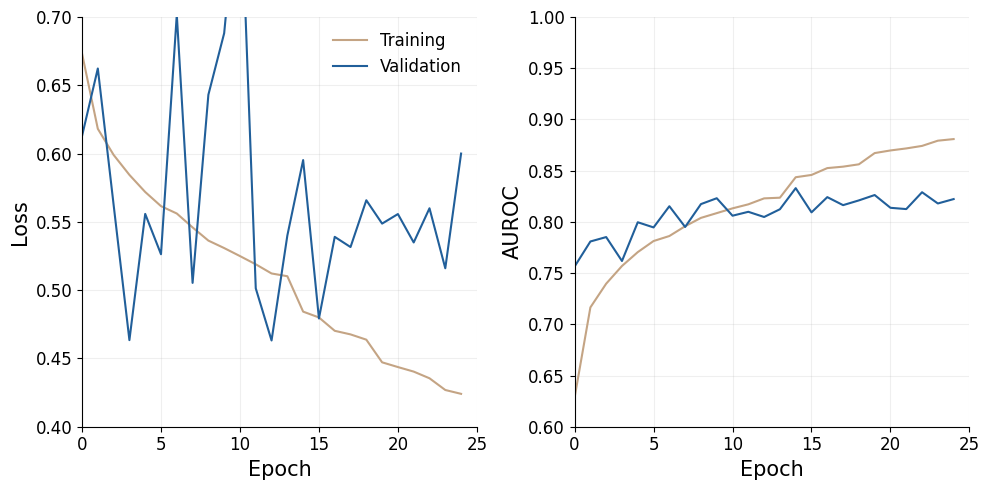

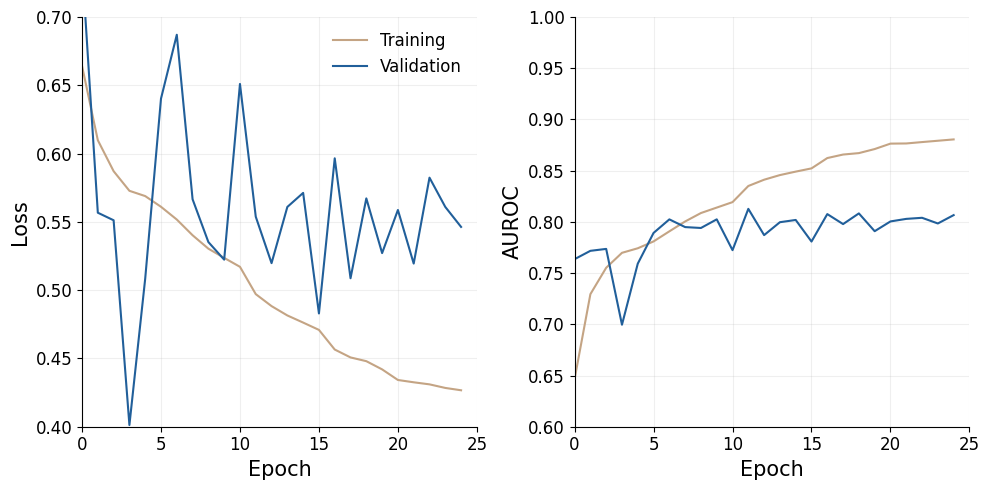

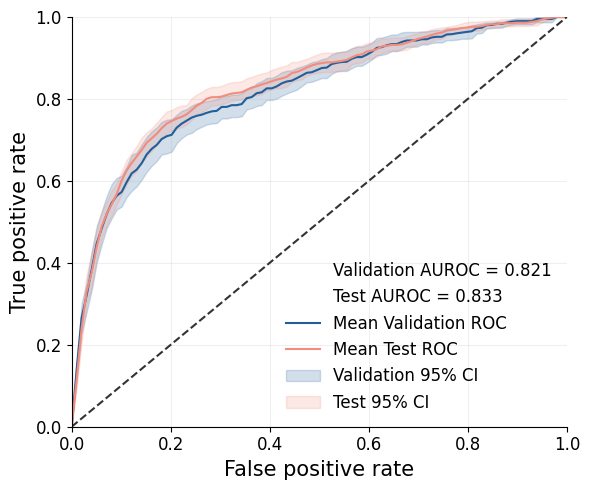

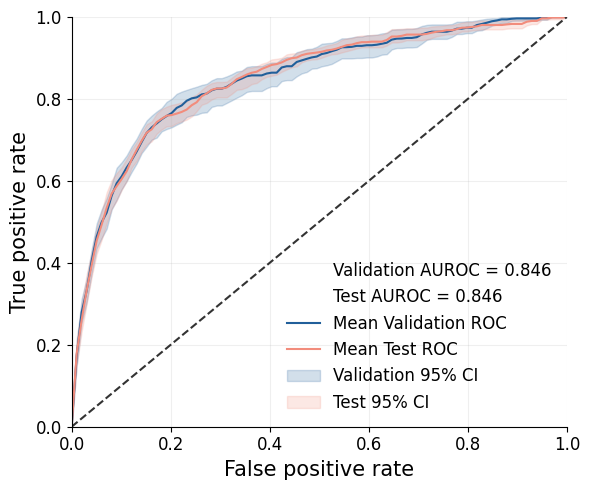

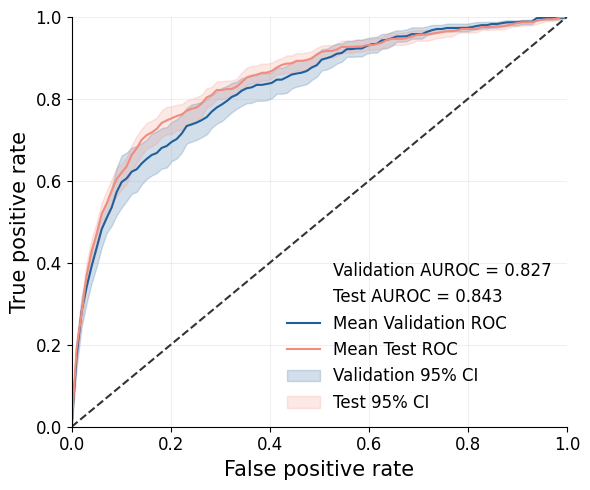

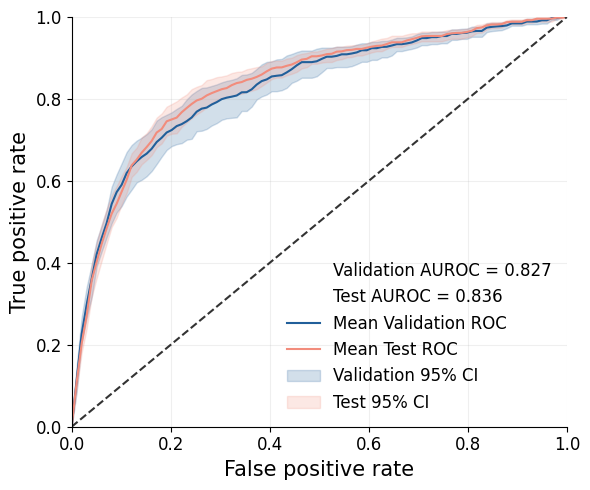

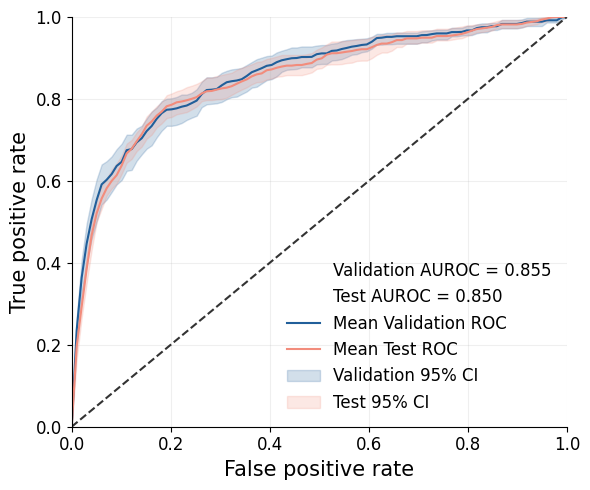

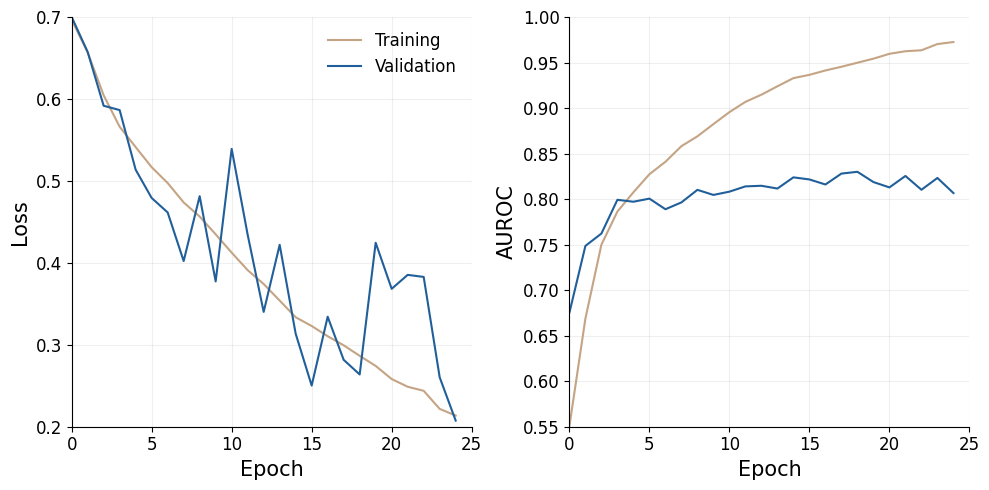

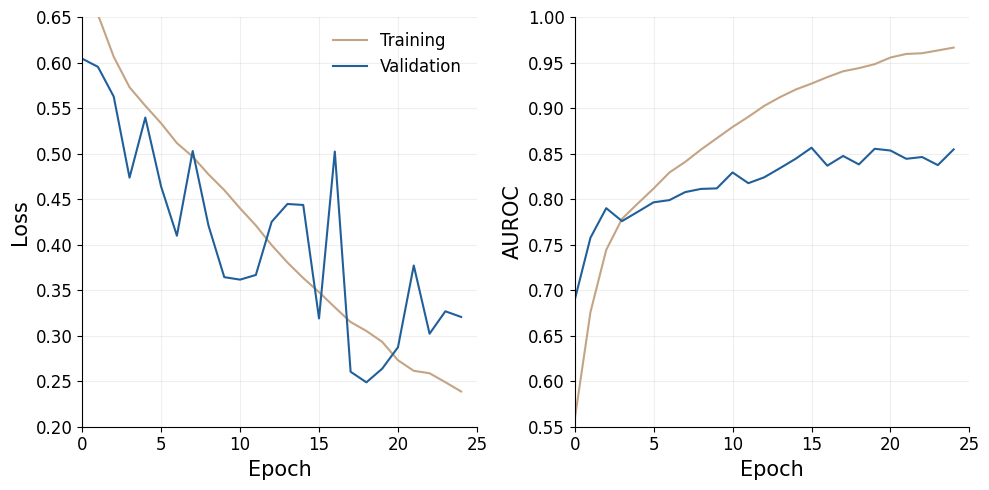

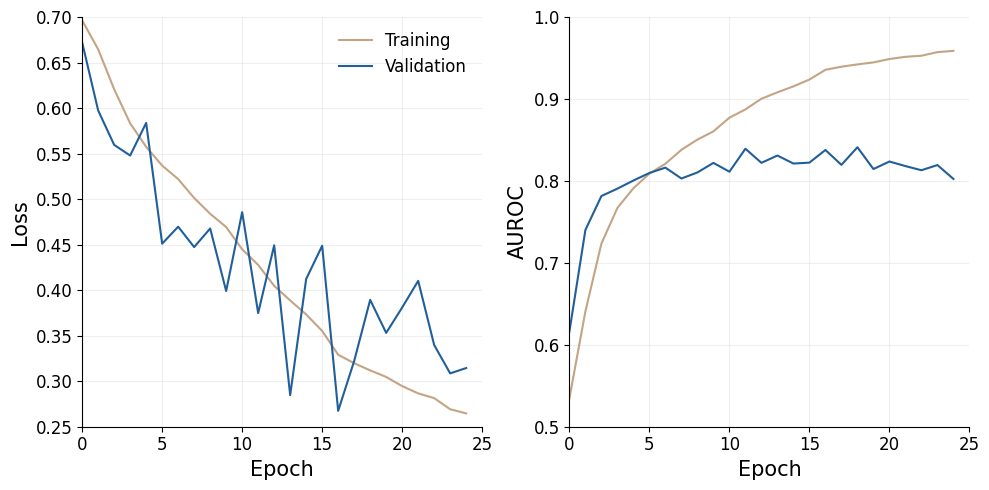

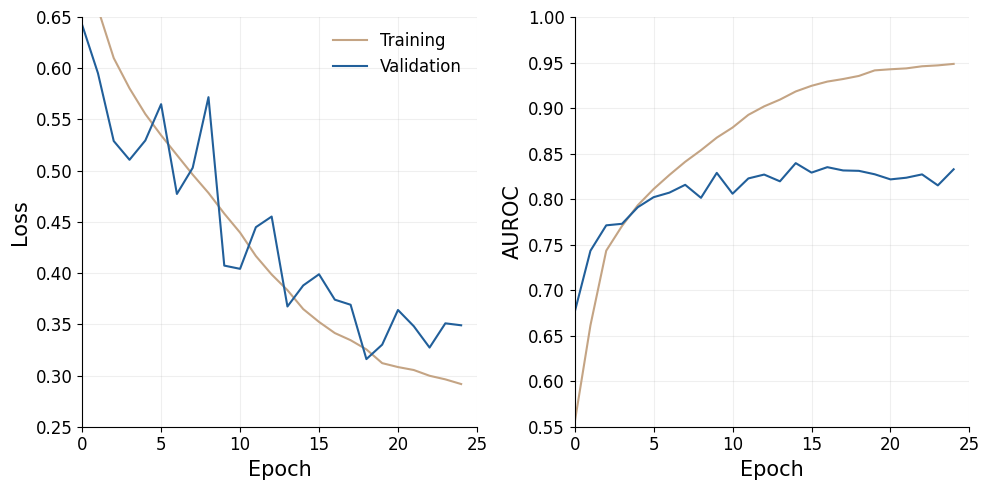

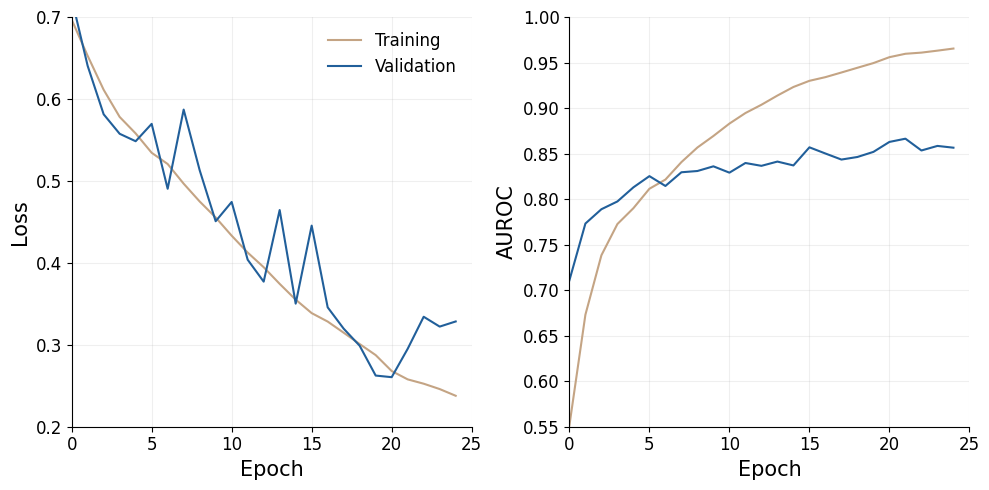

In [ ]:
from hapcancer.cli.functions import eval_metrics_best_api, eval_explain_best_api
from hapcancer.eval.log_manager import TuningLogManager

# -- BASE CONFIGURATION
config_dir = "path_to"
config_defaults = {
    "birads_classifier": "birads_clf_001.yml",
    "embeddings": "tfidf_001.yml",
    "split": "split_002.yml",
    "followup": "fix_grace_90_birads5_interval_6.yml", # -- not relevant for this phase, but probably going to raise an error if 'None'
    "bmi_model": None,
    "tuning": "bce_filtering_shortcuts.yml",
    "training_experiments": "base.yml",
    "eval": None
}

target_years = [ 2, 1 ]
fractions = [ 0.01, 0.025 ] 

strat_str = config_defaults["followup"].split(".")[0]
split_str = config_defaults["split"].split(".")[0]

tuninglog = TuningLogManager(config_dir, config_defaults)
best_params = { yr: tuninglog.get_best_trial_params(strat_str, target_year=yr, split_str=split_str) for yr in target_years }
best_params_names = { yr: tuninglog.get_model_name(trial_number=best_params[yr][0], strat_str=strat_str, target_year=yr, split_str=split_str) for yr in target_years }

for yr in target_years:
    print(yr, best_params[yr])
    print(yr, best_params_names[yr])
    print("--")

# ------------------------------------------------------
# 1. Evaluation: Discrimination and calibration metrics
# ------------------------------------------------------
for ix, cur_target_year in enumerate(target_years):
    print(f"Target year: {cur_target_year}")
    eval_metrics_best_api(
        config_dir=config_dir,
        config_defaults=config_defaults,
        target_year=cur_target_year,
        ablate=False # True only when performing the experiment without text
    )

    #eval_explain_best_api(
    #    config_dir=config_dir,
    #    config_defaults=config_defaults,
    #    target_year=cur_target_year,
    #    fraction=fractions[ix],
    #    ablate=False
    #)